# m11 — Up Supplement Training

Same architecture as m5c (GazeNetM5, 4-class) with two changes:

1. **Training data expanded**: main GazeCapture tars + Keta's GazeCapture supplement (~11k Up) + XGaze supplement (~13k mixed)
2. **Updated files**: `gaze_labels_v2.csv` and `geo_features_v2.parquet` covering all three sources

Everything else (architecture, augmentation, class weights, loss) is identical to m5c so results are directly comparable.

---
**Pre-flight checklist (do before running):**
- [ ] `gaze_labels_v2.csv` uploaded to `MyDrive/210/`
- [ ] `geo_features_v2.parquet` uploaded to `MyDrive/210/`
- [ ] Keta supplement tars uploaded to `MyDrive/210/gaze_wds_supplement/train/`
- [ ] XGaze tars already in `MyDrive/210/gaze_wds_balanced/train/` ✓ (already there)
- [ ] AWS credentials added to Colab Secrets (if streaming supplement from S3 instead)

In [1]:
# ============================================================
# INSTALL
# ============================================================
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.2 MB/s eta 0:00:00


In [11]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# ============================================================
# IMPORT TORCH
# ============================================================
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
# ============================================================
# IMPORTS
# ============================================================

import os, glob, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# ============================================================
# ALL PATHS
# ============================================================

# Local Colab disk (fast — tars copied here before training)
TAR_DIR_MAIN  = "/content/gaze_wds_balanced"
TAR_DIR_SUPP  = "/content/gaze_wds_supplement"

# Drive sources
DRIVE_MAIN    = "/content/drive/MyDrive/210/gaze_wds_balanced"
DRIVE_SUPP    = "/content/drive/MyDrive/210/gaze_wds_supplement"

# v2 label and geo files
LABELS_CSV    = "/content/drive/MyDrive/210/gaze_labels_v2.csv"
GEO_PARQUET   = "/content/drive/MyDrive/210/geo_features_v2.parquet"

MODEL_NAME        = "m11"
CHECKPOINT_BEST   = f"/content/drive/MyDrive/210/{MODEL_NAME}_best.pth"
CHECKPOINT_BESTGAP = f"/content/drive/MyDrive/210/{MODEL_NAME}_bestgap.pth"

print(f"Labels:     {LABELS_CSV}")
print(f"Geo:        {GEO_PARQUET}")
print(f"Checkpoint (best):    {CHECKPOINT_BEST}")
print(f"Checkpoint (bestgap): {CHECKPOINT_BESTGAP}")

Labels:     /content/drive/MyDrive/210/gaze_labels_v2.csv
Geo:        /content/drive/MyDrive/210/geo_features_v2.parquet
Checkpoint (best):    /content/drive/MyDrive/210/m11_best.pth
Checkpoint (bestgap): /content/drive/MyDrive/210/m11_bestgap.pth


In [6]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK
#
# Copies from Drive to local disk for fast I/O during training.
# Main tars: train / val / test splits
# Supplement tars: train only (no val/test)
# XGaze tars are already mixed into gaze_wds_balanced/train
# ============================================================

# Main dataset splits
for split in ['train', 'val', 'test']:
    local_dir = f'{TAR_DIR_MAIN}/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'{DRIVE_MAIN}/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        dest = f"{local_dir}/{os.path.basename(f)}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"main/{split}: {count} tars")

# Keta supplement (train only)
supp_local = f'{TAR_DIR_SUPP}/train'
os.makedirs(supp_local, exist_ok=True)
supp_src = f'{DRIVE_SUPP}/train/'
supp_tars = sorted(glob.glob(supp_src + '*.tar'))
for f in supp_tars:
    dest = f"{supp_local}/{os.path.basename(f)}"
    if not os.path.exists(dest):
        os.system(f"cp '{f}' '{dest}'")
count = len([f for f in os.listdir(supp_local) if f.endswith('.tar')])
print(f"supplement/train: {count} tars")

main/train: 75 tars
main/val: 16 tars
main/test: 16 tars
supplement/train: 7 tars


In [12]:
# ============================================================
# VERIFY FILES
# ============================================================

main_train_tars = sorted(glob.glob(f"{TAR_DIR_MAIN}/train/*.tar"))
supp_train_tars = sorted(glob.glob(f"{TAR_DIR_SUPP}/train/*.tar"))
val_tar_urls    = sorted(glob.glob(f"{TAR_DIR_MAIN}/val/*.tar"))
test_tar_urls   = sorted(glob.glob(f"{TAR_DIR_MAIN}/test/*.tar"))

# Combined training URL list — WDS will interleave via shardshuffle
train_tar_urls = main_train_tars + supp_train_tars

print(f"Main train tars:  {len(main_train_tars)}")
print(f"Supp train tars:  {len(supp_train_tars)}")
print(f"Total train tars: {len(train_tar_urls)}")
print(f"Val tars:         {len(val_tar_urls)}")
print(f"Test tars:        {len(test_tar_urls)}")
print(f"Labels CSV:       {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet:      {os.path.exists(GEO_PARQUET)}")

assert len(supp_train_tars) > 0, "No supplement tars found — upload gaze_wds_supplement/train/ to Drive first."
assert os.path.exists(LABELS_CSV), "gaze_labels_v2.csv not found on Drive."
assert os.path.exists(GEO_PARQUET), "geo_features_v2.parquet not found on Drive."

Main train tars:  75
Supp train tars:  7
Total train tars: 82
Val tars:         16
Test tars:        16
Labels CSV:       True
Geo parquet:      True


In [13]:
# ============================================================
# LOAD LABELS (v2)
#
# gaze_labels_v2.csv has two columns: key, label
# No subject_id/frame_idx — key is pre-built (e.g. '00003_000136')
# All labels are already Title case and Straight-free.
# ============================================================

label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}
VALID_CLASSES = set(label_map_4.keys())

df_labels = pd.read_csv(LABELS_CSV)
print(f"Loaded {len(df_labels)} labeled frames")
print(df_labels['label'].value_counts())

label_lookup_4 = {
    row['key']: row['label']
    for _, row in df_labels.iterrows()
    if row['label'] in VALID_CLASSES
}
print(f"\nLabel lookup: {len(label_lookup_4)} entries")

Loaded 625293 labeled frames
label
Down     214504
Left     189839
Right    181163
Up        39787
Name: count, dtype: int64

Label lookup: 625293 entries


In [14]:
# ============================================================
# LOAD GEO FEATURES (v2)
#
# geo_features_v2.parquet covers all three data sources.
# Same 7 features, same key format as v1.
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['key']] = row[geo_cols].values.astype(np.float32)

print(f"Geo lookup: {len(geo_lookup)} entries")

# ---- Coverage check ----
matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
missing = len(label_lookup_4) - matched
print(f"\nGeo coverage: {matched}/{len(label_lookup_4)} ({100*matched/len(label_lookup_4):.1f}%)")
if missing > 0:
    print(f"  {missing} samples will use GEO_DEFAULT fallback")

GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
print(f"Geo default: {GEO_DEFAULT}")

Loaded geo features: 298538 rows
Geo lookup: 298538 entries

Geo coverage: 220379/625293 (35.2%)
  404914 samples will use GEO_DEFAULT fallback
Geo default: [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


In [15]:
# ============================================================
# IMAGE TRANSFORMS
# Identical to m5c — no horizontal flip (would invalidate labels)
# ============================================================

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [16]:
# ============================================================
# make_dataset_4class
#
# Same as m5c except:
#   - label_lookup_4 now covers GazeCapture + supplement + XGaze
#   - geo_lookup now covers all three sources
#   - shardshuffle interleaves supplement and main tars naturally
# ============================================================

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face      = np.array(sample["face.jpg"])
        left_eye  = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye  = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        return {
            'left_eye':     left_eye,
            'right_eye':    right_eye,
            'face':         face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label':        torch.tensor(label_map_4[label_str], dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


In [17]:
# ============================================================
# GazeNetM5 — Model Definition (unchanged from m5c)
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.ReLU(),
        )

        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        combined   = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
_test = GazeNetM5(num_classes=4)
print(f"Parameters: {sum(p.numel() for p in _test.parameters()):,}")
del _test

GazeNetM5 defined
Parameters: 6,586,820


train: 173168 samples — {0: 29131, 1: 54643, 2: 45715, 3: 43679}
val: 28282 samples — {0: 912, 1: 11055, 2: 8644, 3: 7671}
test: 29770 samples — {0: 867, 1: 11016, 2: 9236, 3: 8651}


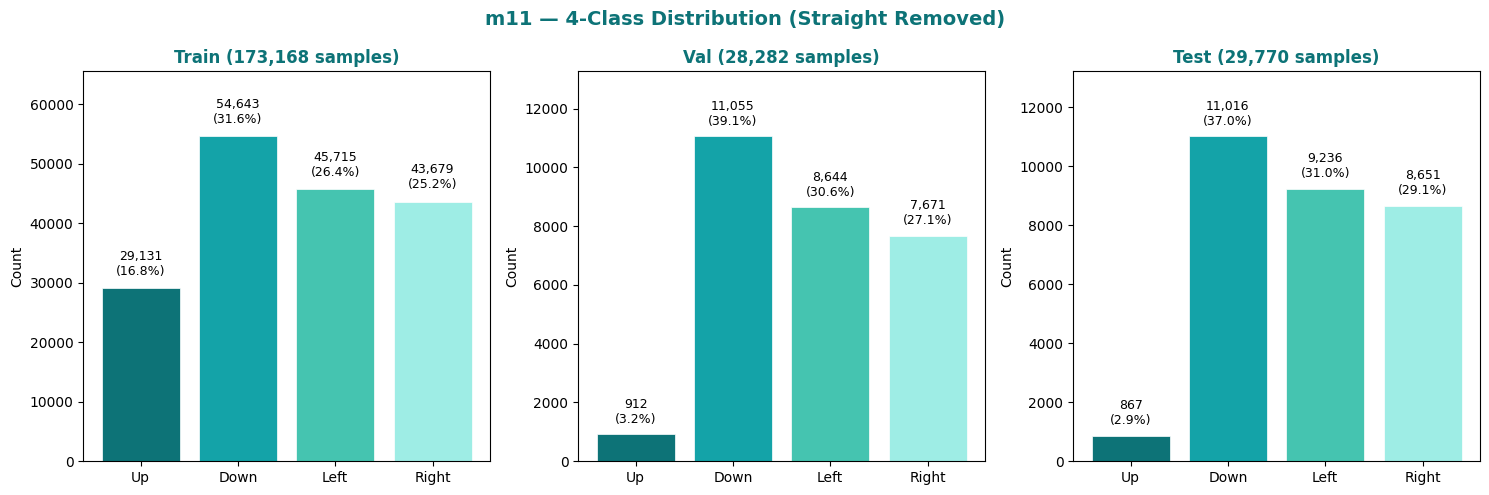


!!! UPDATE train_counts IN THE NEXT CELL WITH THESE VALUES !!!
train_counts = [29131, 54643, 45715, 43679]  # [Up, Down, Left, Right]


In [18]:
# # ============================================================
# # CHECK CLASS BALANCE
# #
# # !!! HUMAN JUDGMENT REQUIRED BEFORE NEXT CELL !!!
# # Run this cell first, then use the printed train counts to
# # update the class weights in the MODEL SETUP cell below.
# # Do NOT skip this — m5c weights were computed on 4,247 Up
# # samples; m11 has ~3x more Up so weights need recalculating.
# # ============================================================

# label_names_map = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
# teal_colors = ['#0D7377', '#14A3A8', '#45C4B0', '#9EEDE5']

# # Build temp loaders just for counting (no augmentation, small batch)
# train_dataset_check = make_dataset_4class(train_tar_urls, eye_transform_clean, face_transform_clean, shuffle=False)
# val_dataset_check   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
# test_dataset_check  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

# train_loader_check = wds.WebLoader(train_dataset_check, batch_size=64, num_workers=2)
# val_loader_check   = wds.WebLoader(val_dataset_check,   batch_size=64, num_workers=2)
# test_loader_check  = wds.WebLoader(test_dataset_check,  batch_size=64, num_workers=2)

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# train_counts_by_class = None

# for ax, (split_name, loader) in zip(axes, [
#     ('train', train_loader_check),
#     ('val',   val_loader_check),
#     ('test',  test_loader_check),
# ]):
#     counts = {i: 0 for i in range(4)}
#     total = 0
#     for batch in loader:
#         for lbl in batch['label'].tolist():
#             counts[lbl] += 1
#             total += 1

#     if split_name == 'train':
#         train_counts_by_class = [counts[i] for i in range(4)]  # [Up, Down, Left, Right]

#     class_names  = [label_names_map[i] for i in range(4)]
#     class_counts = [counts[i] for i in range(4)]
#     bars = ax.bar(class_names, class_counts, color=teal_colors, edgecolor='white', linewidth=0.5)
#     ax.set_title(f'{split_name.capitalize()} ({total:,} samples)', fontsize=12,
#                  fontweight='bold', color='#0D7377')
#     ax.set_ylabel('Count')
#     for bar, c in zip(bars, class_counts):
#         ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
#                 f'{c:,}\n({100*c/total:.1f}%)', ha='center', va='bottom', fontsize=9)
#     ax.set_ylim(0, max(class_counts) * 1.2)
#     print(f"{split_name}: {total} samples — {counts}")

# plt.suptitle('m11 — 4-Class Distribution (Straight Removed)', fontsize=14,
#              fontweight='bold', color='#0D7377')
# plt.tight_layout()
# plt.show()

# print(f"\n!!! UPDATE train_counts IN THE NEXT CELL WITH THESE VALUES !!!")
# print(f"train_counts = {train_counts_by_class}  # [Up, Down, Left, Right]")

In [19]:
# ============================================================
# MODEL SETUP — class weights + optimizer
#
# !!! UPDATE train_counts BELOW with values from previous cell
# before running this cell. !!!
# ============================================================

train_dataset = make_dataset_4class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

model = GazeNetM5(num_classes=4).to(device)

# !!! UPDATE THESE with actual counts from distribution check above !!!
train_counts = [29131, 54643, 45715, 43679]   # [Up, Down, Left, Right]
assert all(c is not None for c in train_counts), \
    "Update train_counts with actual values from the distribution check cell."

total_train = sum(train_counts)
n_classes = 4
weights = [math.sqrt(total_train / (n_classes * c)) for c in train_counts]
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights (sqrt inv freq):")
for name, w, c in zip(['Up', 'Down', 'Left', 'Right'], weights, train_counts):
    print(f"  {name:6s}: {w:.3f}  (n={c:,})")

criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"\nModel: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"FC output shape: {model.fc[-1].weight.shape}  <-- should be [4, 256]")

Class weights (sqrt inv freq):
  Up    : 1.219  (n=29,131)
  Down  : 0.890  (n=54,643)
  Left  : 0.973  (n=45,715)
  Right : 0.996  (n=43,679)

Model: m11
Device: cuda
Parameters: 6,586,820
FC output shape: torch.Size([4, 256])  <-- should be [4, 256]


In [23]:
# check duplicate between original and supplemental tars
# Load supplement geo before dedup — need to reconstruct from v2 minus v1 minus xgaze
xgaze_labels = pd.read_csv("/content/drive/MyDrive/210/xgaze_supplement_labels.csv")
xgaze_keys = set(
    row['subject_id'] + '_' + f"{int(row['frame_idx']):06d}"
    for _, row in xgaze_labels.iterrows()
)

supp_keys = v2_keys - v1_keys - xgaze_keys
print(f"Net new supplement keys (not in v1, not xgaze): {len(supp_keys)}")
print("Sample:", list(supp_keys)[:5])

# The duplicates we care about = keys in supplement tars that ALSO appear in main tars
true_dupes = supp_keys & v1_keys  # should be ~5340 from earlier
print(f"\nTrue dupes (in both main and supplement tars): {len(true_dupes)}")
print("Sample:", list(true_dupes)[:5])

Net new supplement keys (not in v1, not xgaze): 12100
Sample: ['01327_002226', '01435_001035', '00358_002459', '01191_002835', '01237_000909']

True dupes (in both main and supplement tars): 0
Sample: []


In [24]:
# ============================================================
# SMOKE TEST
# ============================================================

# Test one batch from main tars and one from supplement
for label, tar in [('main', main_train_tars[0]), ('supplement', supp_train_tars[0])]:
    test_ds = make_dataset_4class([tar], eye_transform_clean, face_transform_clean, shuffle=False)
    smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)
    batch = next(iter(smoke_loader))
    print(f"[{label}] key batch labels: {batch['label'].tolist()} — shapes: "
          f"face={batch['face'].shape}, geo={batch['geo_features'].shape}")

    model.eval()
    with torch.no_grad():
        out = model(
            batch['left_eye'].to(device),
            batch['right_eye'].to(device),
            batch['face'].to(device),
            batch['geo_features'].to(device),
        )
    print(f"  Output shape: {out.shape}  <-- should be [4, 4]")

print("\nSmoke test passed!")

[main] key batch labels: [1, 1, 1, 1] — shapes: face=torch.Size([4, 3, 112, 112]), geo=torch.Size([4, 7])
  Output shape: torch.Size([4, 4])  <-- should be [4, 4]
[supplement] key batch labels: [2, 0, 1, 1] — shapes: face=torch.Size([4, 3, 112, 112]), geo=torch.Size([4, 7])
  Output shape: torch.Size([4, 4])  <-- should be [4, 4]

Smoke test passed!


In [25]:
# ============================================================
# TRAINING LOOP
#
# Two checkpoints saved:
#   _best.pth    — lowest val loss (primary)
#   _bestgap.pth — smallest train-val gap while val acc > 90%
# ============================================================

num_epochs  = 20
patience    = 6
patience_counter = 0
best_val_loss    = float('inf')
best_gap         = float('inf')
best_gap_epoch   = -1

train_losses      = []
val_losses        = []
train_accuracies  = []
val_accuracies    = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ---- Training ----
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            eta = (elapsed / (batch_idx + 1)) * (7000 - (batch_idx + 1)) / 60
            print(f"  Batch {batch_idx+1}/~7000 — Loss: {loss.item():.4f} — ETA: {eta:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total

    # ---- Validation ----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total
    gap = train_acc - val_acc

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    epoch_time = time.time() - epoch_start
    print(f"\n  Time:       {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap:        {gap:.2f}%")

    # Checkpoint 1: best val loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_BEST)
        print(f"  ✓ Saved _best.pth (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    # Checkpoint 2: smallest gap while val acc > 90%
    if val_acc >= 90.0 and gap < best_gap:
        best_gap = gap
        best_gap_epoch = epoch + 1
        torch.save(model.state_dict(), CHECKPOINT_BESTGAP)
        print(f"  ✓ Saved _bestgap.pth (gap={gap:.2f}%, val_acc={val_acc:.2f}%)")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

print(f"\nTraining complete!")
print(f"Best val loss:  {best_val_loss:.4f}")
print(f"Best gap epoch: {best_gap_epoch} (gap={best_gap:.2f}%)")


Epoch 1/20
  Batch 1000/~7000 — Loss: 0.8627 — ETA: 13.5 min
  Batch 2000/~7000 — Loss: 0.7951 — ETA: 11.3 min
  Batch 3000/~7000 — Loss: 0.5980 — ETA: 8.9 min
  Batch 4000/~7000 — Loss: 0.5650 — ETA: 6.5 min
  Batch 5000/~7000 — Loss: 0.5504 — ETA: 4.3 min

  Time:       13.1 min
  Train Loss: 0.7352 | Train Acc: 81.53%
  Val Loss:   0.5877 | Val Acc:   90.31%
  Gap:        -8.78%
  ✓ Saved _best.pth (val_loss=0.5877)
  ✓ Saved _bestgap.pth (gap=-8.78%, val_acc=90.31%)

Epoch 2/20
  Batch 1000/~7000 — Loss: 0.6094 — ETA: 13.2 min
  Batch 2000/~7000 — Loss: 0.3999 — ETA: 11.1 min
  Batch 3000/~7000 — Loss: 0.5232 — ETA: 8.7 min
  Batch 4000/~7000 — Loss: 0.7843 — ETA: 6.4 min
  Batch 5000/~7000 — Loss: 0.4397 — ETA: 4.2 min

  Time:       12.9 min
  Train Loss: 0.5773 | Train Acc: 90.27%
  Val Loss:   0.5600 | Val Acc:   91.19%
  Gap:        -0.92%
  ✓ Saved _best.pth (val_loss=0.5600)

Epoch 3/20
  Batch 1000/~7000 — Loss: 0.6117 — ETA: 13.4 min
  Batch 2000/~7000 — Loss: 0.4501 — ET

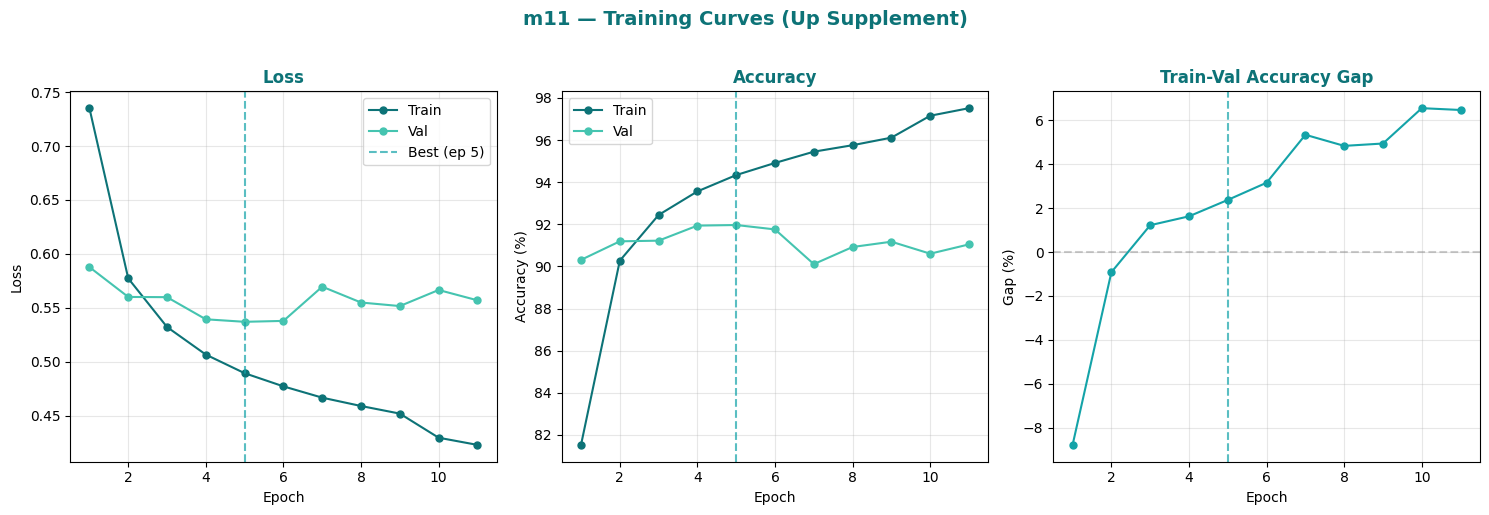


Training Summary (at best checkpoint)
Best epoch:       5
Best val loss:    0.5370
Val acc at best:  91.97%
Train acc at best:94.34%
Gap at best:      2.37%
Best gap epoch:   1 (gap=-8.78%)


In [26]:
# ============================================================
# TRAINING CURVES — Teal theme, 3-panel
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

best_epoch = val_losses.index(min(val_losses)) + 1
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loss
ax = axes[0]
ax.plot(epochs_range, train_losses, '-o', color=teal_dark,  label='Train', markersize=5)
ax.plot(epochs_range, val_losses,   '-o', color=teal_light, label='Val',   markersize=5)
ax.axvline(x=best_epoch, color=teal_mid, linestyle='--', alpha=0.7, label=f'Best (ep {best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss', fontweight='bold', color=teal_dark)
ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs_range, train_accuracies, '-o', color=teal_dark,  label='Train', markersize=5)
ax.plot(epochs_range, val_accuracies,   '-o', color=teal_light, label='Val',   markersize=5)
ax.axvline(x=best_epoch, color=teal_mid, linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy', fontweight='bold', color=teal_dark)
ax.legend(); ax.grid(True, alpha=0.3)

# Overfitting gap
ax = axes[2]
gap_curve = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(epochs_range, gap_curve, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=best_epoch, color=teal_mid, linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — Training Curves (Up Supplement)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Training Summary (at best checkpoint)")
print("="*50)
print(f"Best epoch:       {best_epoch}")
print(f"Best val loss:    {min(val_losses):.4f}")
print(f"Val acc at best:  {val_accuracies[best_epoch-1]:.2f}%")
print(f"Train acc at best:{train_accuracies[best_epoch-1]:.2f}%")
print(f"Gap at best:      {train_accuracies[best_epoch-1] - val_accuracies[best_epoch-1]:.2f}%")
print(f"Best gap epoch:   {best_gap_epoch} (gap={best_gap:.2f}%)")

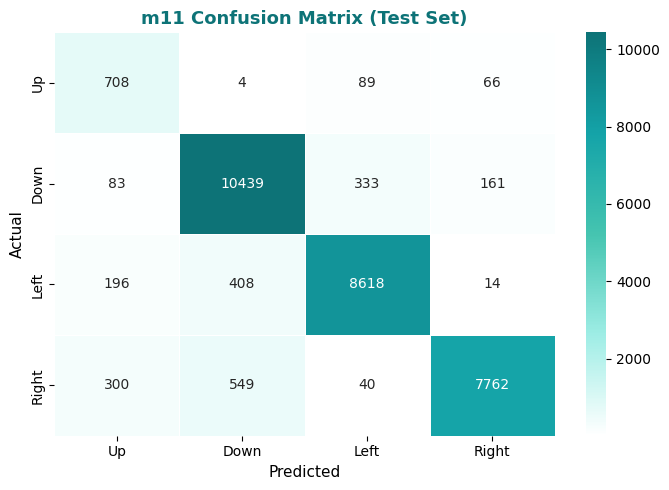


m11 Test Set Performance
              precision    recall  f1-score   support

          Up       0.55      0.82      0.66       867
        Down       0.92      0.95      0.93     11016
        Left       0.95      0.93      0.94      9236
       Right       0.97      0.90      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.85      0.90      0.87     29770
weighted avg       0.93      0.92      0.93     29770



In [27]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_BEST))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            batch['left_eye'].to(device),
            batch['right_eye'].to(device),
            batch['face'].to(device),
            batch['geo_features'].to(device),
        )
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch['label'].numpy())

label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)
teal_cmap = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set)',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

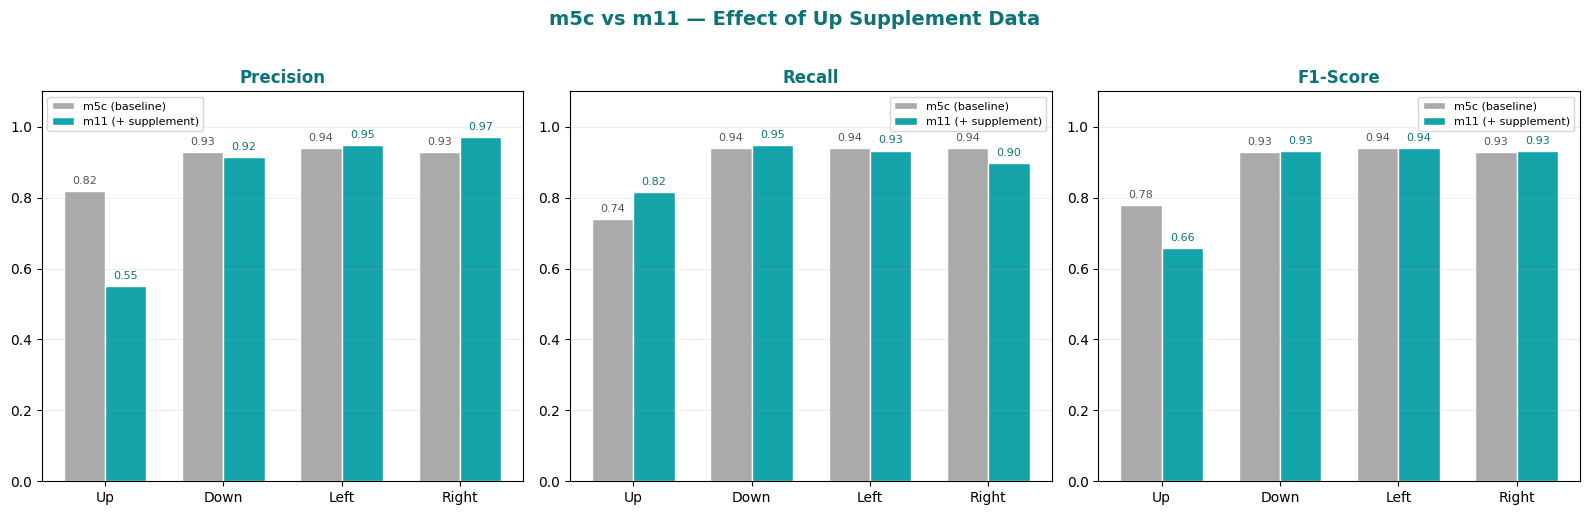


Per-Class Delta: m11 minus m5c (positive = m11 better)
Class      Prec Δ   Recall Δ     F1 Δ
------------------------------------------------------------
Up         -0.270     +0.077   -0.123
Down       -0.014     +0.008   +0.001
Left       +0.009     -0.007   +0.001
Right      +0.040     -0.043   +0.002


In [28]:
# ============================================================
# m5c vs m11 COMPARISON
# Isolates the effect of adding the Up supplement data.
# ============================================================

m5c_report = {
    'Up':    {'precision': 0.82, 'recall': 0.74, 'f1': 0.78, 'support': 867},
    'Down':  {'precision': 0.93, 'recall': 0.94, 'f1': 0.93, 'support': 11016},
    'Left':  {'precision': 0.94, 'recall': 0.94, 'f1': 0.94, 'support': 9236},
    'Right': {'precision': 0.93, 'recall': 0.94, 'f1': 0.93, 'support': 8651},
}

p, r, f, s = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1,2,3])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(4)
width = 0.35

for ax, key, m11_vals, title in [
    (axes[0], 'precision', p, 'Precision'),
    (axes[1], 'recall',    r, 'Recall'),
    (axes[2], 'f1',        f, 'F1-Score'),
]:
    m5c_vals = [m5c_report[c][key] for c in label_names]
    bars1 = ax.bar(x - width/2, m5c_vals,  width, label='m5c (baseline)', color='#AAAAAA', edgecolor='white')
    bars2 = ax.bar(x + width/2, m11_vals, width, label='m11 (+ supplement)', color='#14A3A8', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontweight='bold', color='#0D7377')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#555555')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, color='#0D7377')

plt.suptitle('m5c vs m11 — Effect of Up Supplement Data',
             fontsize=14, fontweight='bold', color='#0D7377', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Per-Class Delta: m11 minus m5c (positive = m11 better)")
print("="*60)
print(f"{'Class':8s} {'Prec Δ':>8s} {'Recall Δ':>10s} {'F1 Δ':>8s}")
print("-"*60)
for i, name in enumerate(label_names):
    dp = p[i] - m5c_report[name]['precision']
    dr = r[i] - m5c_report[name]['recall']
    df_val = f[i] - m5c_report[name]['f1']
    print(f"{name:8s} {dp:>+8.3f} {dr:>+10.3f} {df_val:>+8.3f}")
print("="*60)

In [29]:
# ============================================================
# SAVE TRAINING CURVES & CONFIRM CHECKPOINTS
# ============================================================

print("train_losses_m11 =", train_losses)
print("val_losses_m11 =", val_losses)
print("train_acc_m11 =", train_accuracies)
print("val_acc_m11 =", val_accuracies)

print(f"\nCheckpoint (_best):    {os.path.exists(CHECKPOINT_BEST)} — "
      f"{os.path.getsize(CHECKPOINT_BEST)/1e6:.1f} MB")
print(f"Checkpoint (_bestgap): {os.path.exists(CHECKPOINT_BESTGAP)} — "
      f"{os.path.getsize(CHECKPOINT_BESTGAP)/1e6:.1f} MB")

train_losses_m11 = [0.7351957405976705, 0.5772741735477049, 0.5321440569369603, 0.5065433092727781, 0.4892836688033054, 0.4770654805889637, 0.466583754733114, 0.4588488326558515, 0.45178968894730515, 0.4294169155810955, 0.4227673404652377]
val_losses_m11 = [0.587731529124039, 0.5600405908573819, 0.559827752268247, 0.5392969962904008, 0.5369704241806504, 0.5378095481018562, 0.5695556554417153, 0.5548666689018745, 0.5515747520883204, 0.5664966700103997, 0.556920137715205]
train_acc_m11 = [81.52949736671903, 90.2730296590594, 92.44375404231728, 93.56289845698974, 94.33786842834704, 94.91303243093412, 95.44777326064862, 95.75556684837845, 96.11417813914811, 97.15420862976994, 97.51339739443777]
val_acc_m11 = [90.31185913301746, 91.19227777384909, 91.22410013436108, 91.93833533696343, 91.96662187964075, 91.75800862739551, 90.11031751644155, 90.92355561841454, 91.17459868467577, 90.60533201329467, 91.04730924262782]

Checkpoint (_best):    True — 26.4 MB
Checkpoint (_bestgap): True — 26.4 MB